<a href="https://colab.research.google.com/github/thulubbs23-cpu/Analytic-Projects-in-Python-EDA/blob/master/GROUP_PROJECT_MIS_315.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

#1. Data Preparation



In [ ]:
df = pd.read_excel('B13 Housing Price.xlsx')

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No.                       155 non-null    int64  
 1   Property type             155 non-null    object 
 2   Price (£)                 155 non-null    int64  
 3   Bed                       155 non-null    int64  
 4   Bath                      155 non-null    int64  
 5   Nearest 
station (miles)  155 non-null    float64
 6   Nearest
school            155 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 8.6+ KB


=> No missing values are found.

In [ ]:
df.describe()

,No.,Price (£),Bed,Bath,Nearest \nstation (miles),Nearest\nschool
count,155.000000,1.550000e+02,155.000000,155.000000,155.000000,155.000000
mean,44.129032,3.657944e+05,3.019355,1.438710,1.210323,0.208387
std,29.331006,2.271643e+05,1.281593,0.635363,0.414850,0.118407
min,1.000000,5.000000e+04,1.000000,1.000000,0.400000,0.000000
25%,20.000000,2.125000e+05,2.000000,1.000000,0.850000,0.100000
50%,39.000000,3.100000e+05,3.000000,1.000000,1.300000,0.200000
75%,66.500000,4.750000e+05,4.000000,2.000000,1.550000,0.300000
max,105.000000,1.200000e+06,8.000000,3.000000,2.600000,0.500000


In [ ]:
print(df.head())

   No.  Property type  Price (£)  Bed  Bath  Nearest \nstation (miles)  \
0    1      Apartment     299950    3     2                        1.4   
1    2      Apartment     185000    2     1                        1.5   
2    3  Semi-detached      91000    4     2                        1.4   
3    4      Apartment      75000    1     1                        1.6   
4    5       Terraced     270000    3     1                        0.5   

   Nearest\nschool  
0              0.1  
1              0.1  
2              0.5  
3              0.2  
4              0.2  


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No.                       155 non-null    int64  
 1   Property type             155 non-null    object 
 2   Price (£)                 155 non-null    int64  
 3   Bed                       155 non-null    int64  
 4   Bath                      155 non-null    int64  
 5   Nearest 
station (miles)  155 non-null    float64
 6   Nearest
school            155 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 8.6+ KB
None


NO MISSING VALUES

In [ ]:
# Clean column names by removing leading/trailing spaces and newline characters (\n)
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
# Remove the duplicate serial number column ('No.')
df = df.drop(columns=['No.'], errors='ignore')

In [ ]:
# Check and remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Property type            152 non-null    object 
 1   Price (£)                152 non-null    int64  
 2   Bed                      152 non-null    int64  
 3   Bath                     152 non-null    int64  
 4   Nearest station (miles)  152 non-null    float64
 5   Nearest school           152 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 7.3+ KB
None


In [ ]:
# Detect and remove outliers in the Price variable using the IQR method
Q1 = df['Price (£)'].quantile(0.25)
Q3 = df['Price (£)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers to improve model reliability and reduce the influence of extreme observations
df_clean = df[(df['Price (£)'] >= lower_bound) & (df['Price (£)'] <= upper_bound)].reset_index(drop=True)
print(f" Number of observations after outlier removal: {df_clean.shape[0]}")

# Convert the categorical variable 'Property type' into dummy variables using One-Hot Encoding to enable its inclusion in the regression model
df_model = pd.get_dummies(df_clean, columns=['Property type'], drop_first=True)  # drop_first=True is used to avoid the Dummy Variable Trap and reduce multicollinearity
print(df_model.head())

 Number of observations after outlier removal: 146
   Price (£)  Bed  Bath  Nearest station (miles)  Nearest school  \
0     299950    3     2                      1.4             0.1   
1     185000    2     1                      1.5             0.1   
2      91000    4     2                      1.4             0.5   
3      75000    1     1                      1.6             0.2   
4     270000    3     1                      0.5             0.2   

   Property type_Detached  Property type_Semi-detached  Property type_Terraced  
0                   False                        False                   False  
1                   False                        False                   False  
2                   False                         True                   False  
3                   False                        False                   False  
4                   False                        False                    True  


In [ ]:
# Specify dtype=int to create numerical dummy variables suitable for regression analysis
df_model = pd.get_dummies(df_clean, columns=['Property type'], drop_first=True, dtype=int)
print(df_model.head())

   Price (£)  Bed  Bath  Nearest station (miles)  Nearest school  \
0     299950    3     2                      1.4             0.1   
1     185000    2     1                      1.5             0.1   
2      91000    4     2                      1.4             0.5   
3      75000    1     1                      1.6             0.2   
4     270000    3     1                      0.5             0.2   

   Property type_Detached  Property type_Semi-detached  Property type_Terraced  
0                       0                            0                       0  
1                       0                            0                       0  
2                       0                            1                       0  
3                       0                            0                       0  
4                       0                            0                       1  


In [ ]:

print("Rows after removing duplicates:", len(df))

outliers_removed = len(df) - len(df_clean)
print("Outliers removed:", outliers_removed)

Rows after removing duplicates: 152
Outliers removed: 6


#2. Exploratory Data Analysis (EDA)



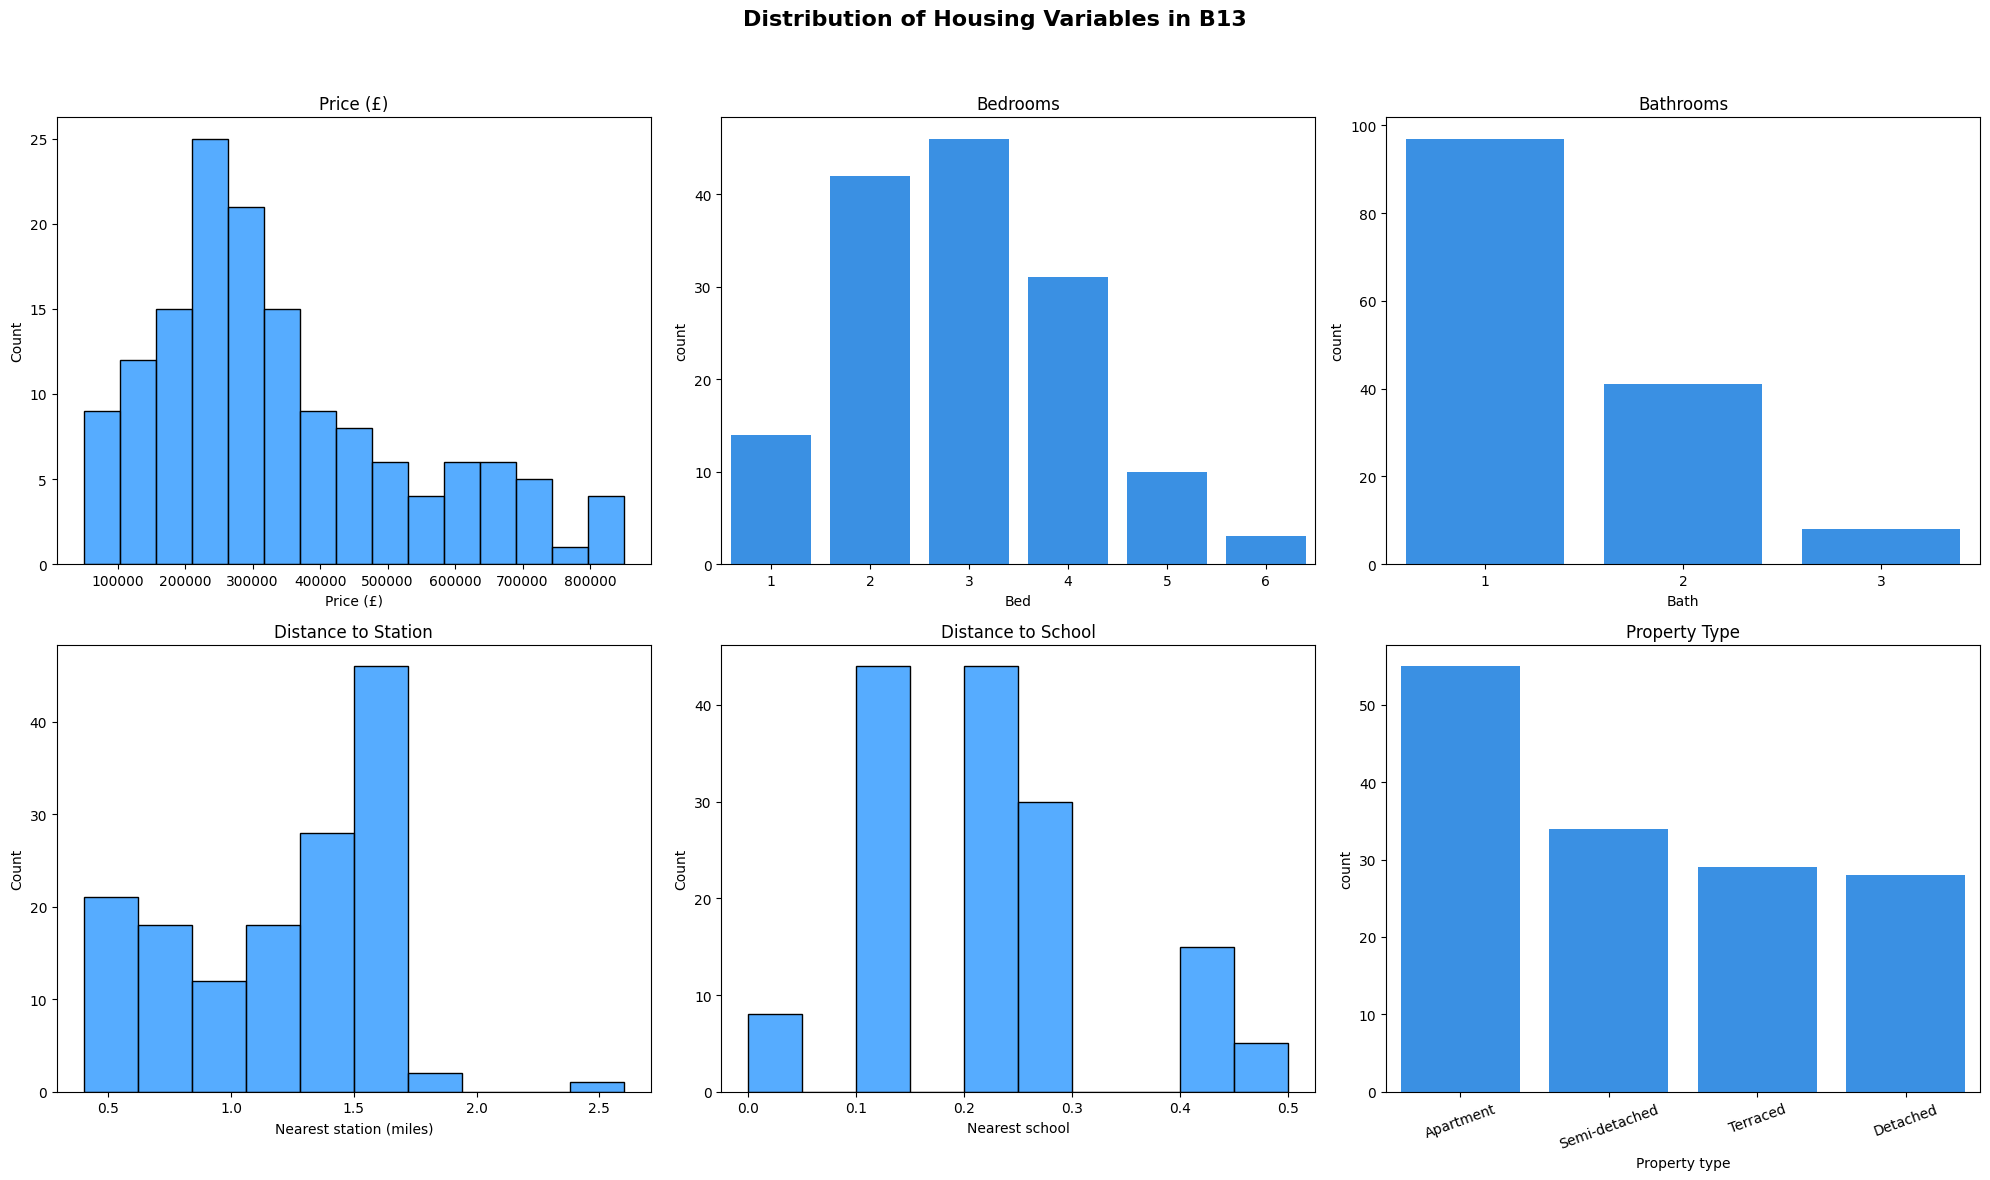

In [ ]:

# Set up the matplotlib figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes = axes.flatten()

# Price
sns.histplot(df_clean['Price (£)'], bins=15, color='dodgerblue', ax=axes[0])
axes[0].set_title('Price (£)')

# Bed
sns.countplot(data=df_clean, x='Bed', color='dodgerblue', ax=axes[1])
axes[1].set_title('Bedrooms')

# Bath
sns.countplot(data=df_clean, x='Bath', color='dodgerblue', ax=axes[2])
axes[2].set_title('Bathrooms')

# Station
sns.histplot(df_clean['Nearest station (miles)'], bins=10,
             color='dodgerblue', ax=axes[3])
axes[3].set_title('Distance to Station')

# School
sns.histplot(df_clean['Nearest school'], bins=10,
             color='dodgerblue', ax=axes[4])
axes[4].set_title('Distance to School')

# Property Type
sns.countplot(
    data=df_clean,
    x='Property type',
    color='dodgerblue',
    ax=axes[5]
)

axes[5].set_title('Property Type')
axes[5].tick_params(axis='x', rotation=20)

#Title
fig.suptitle(
    'Distribution of Housing Variables in B13',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

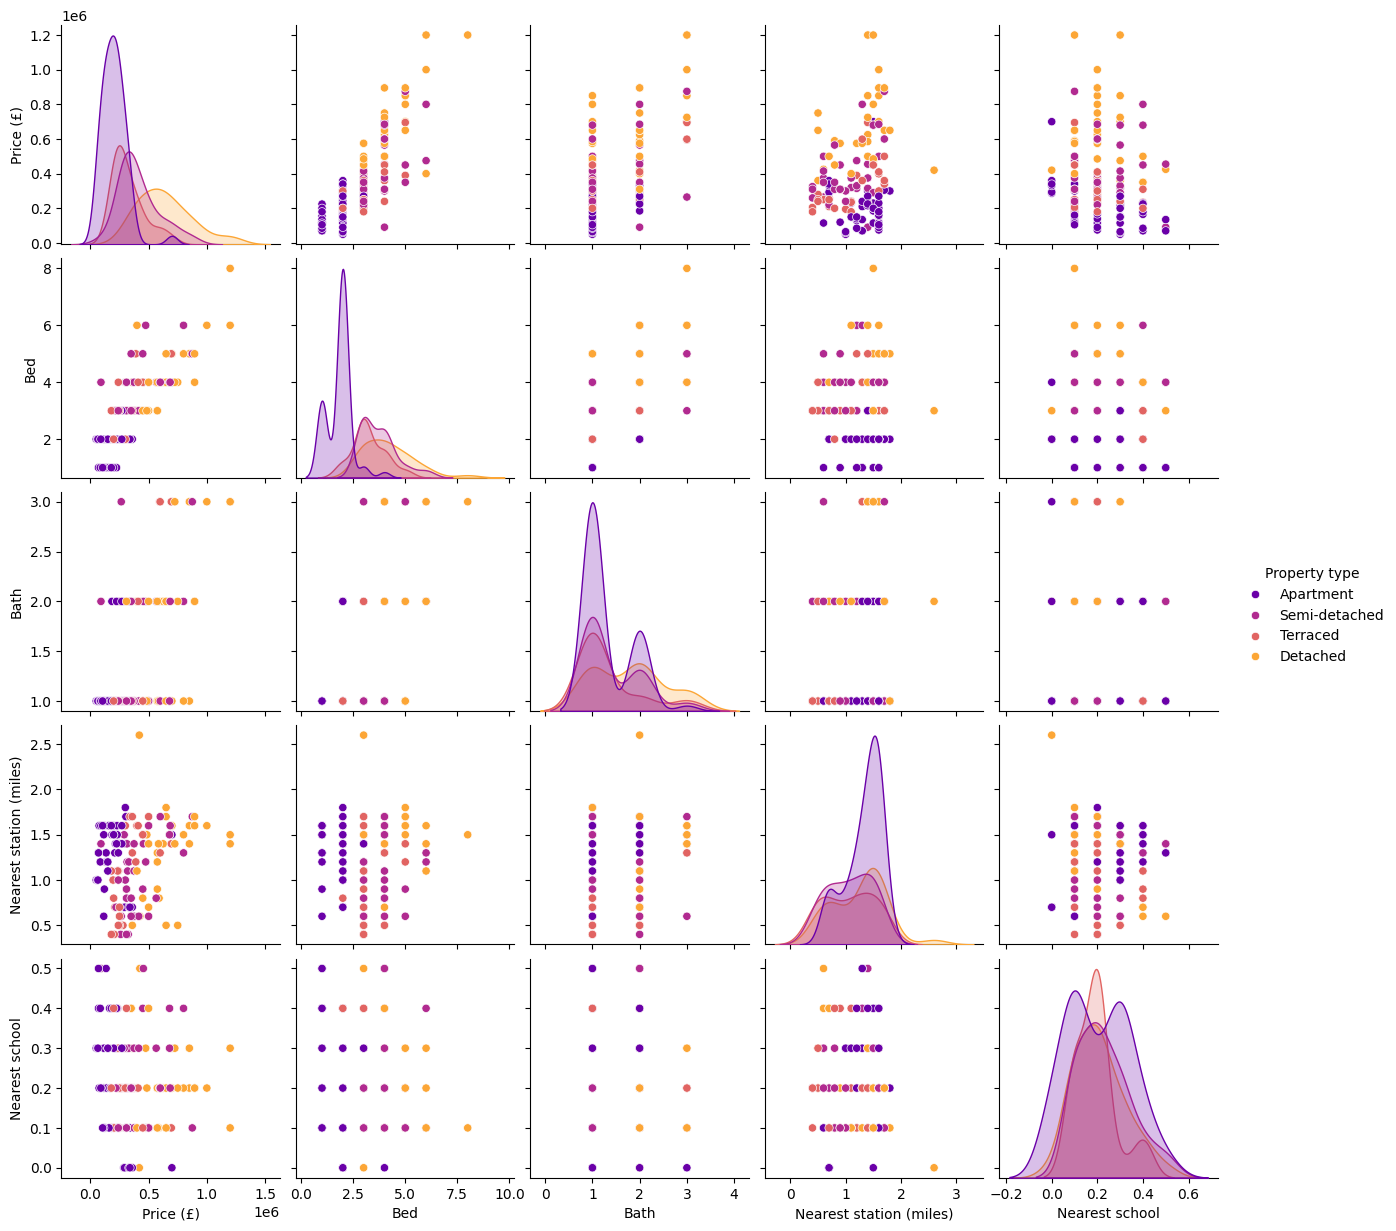

In [ ]:
pair_plot = sns.pairplot(data=df,
                         vars=['Price (£)',
                               'Bed',
                               'Bath',
                               'Nearest station (miles)',
                               'Nearest school'],
                         hue='Property type',
                         diag_kind='kde',
                         palette='plasma')

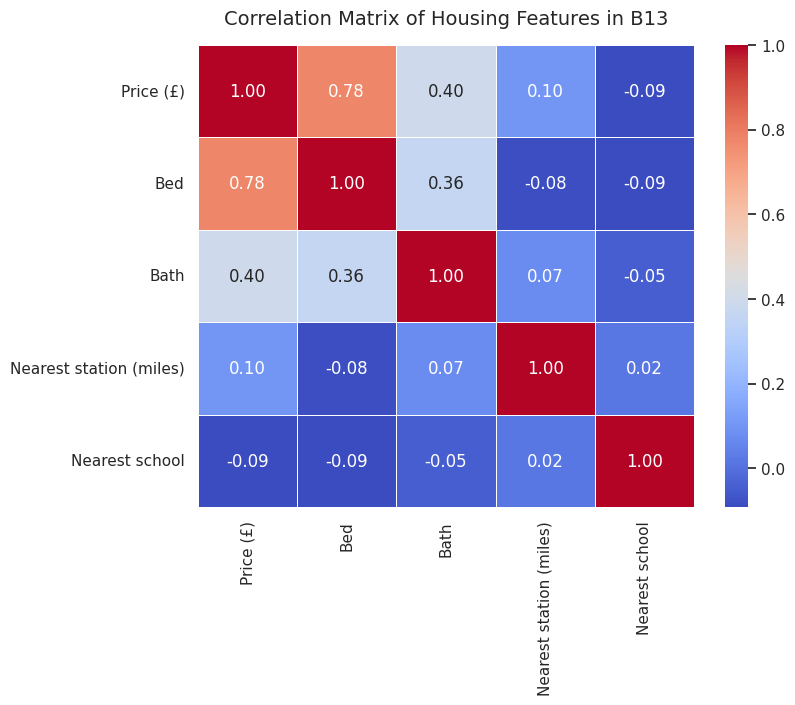

In [ ]:
# Set a better visual style for the plots
sns.set_theme(style="whitegrid")

# Create a correlation heatmap to identify the strength and direction of relationships between variables
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Housing Features in B13', fontsize=14, pad=15)
plt.show()

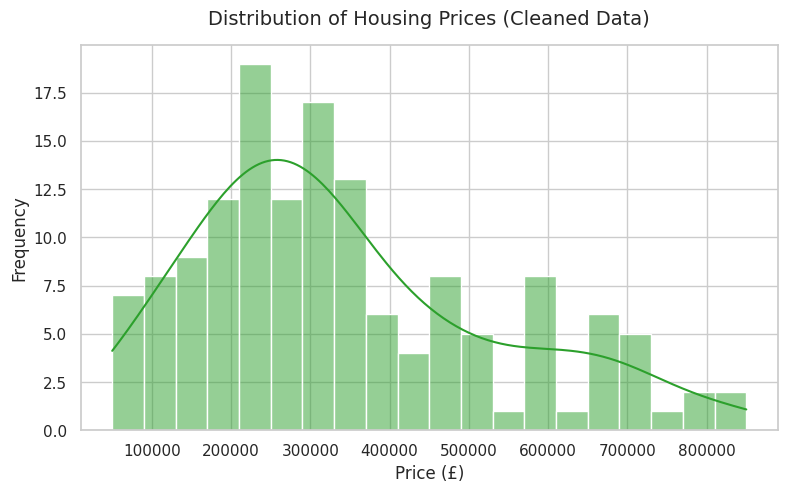

In [ ]:
# Create a histogram to explore the distribution of house prices after outlier treatment and identify overall market patterns
plt.figure(figsize=(9, 5))
sns.histplot(df_clean['Price (£)'], kde=True, color='#2ca02c', bins=20)
plt.title('Distribution of Housing Prices (Cleaned Data)', fontsize=14, pad=15)
plt.xlabel('Price (£)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

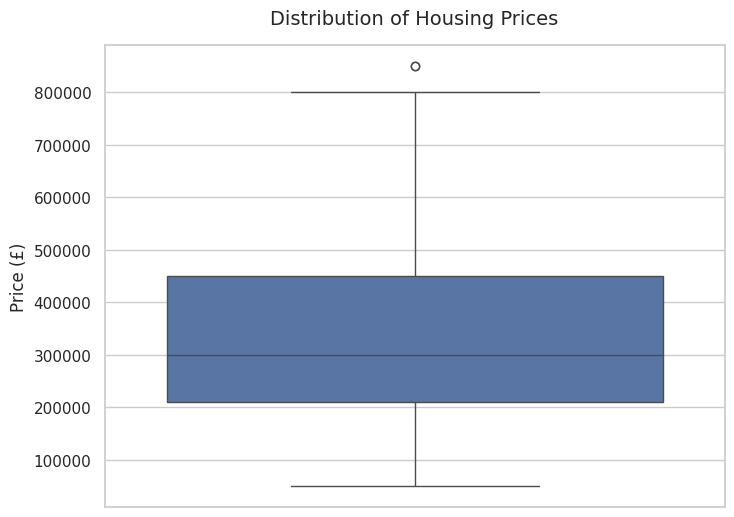

In [ ]:
# Generate a boxplot to examine the distribution of house prices and identify potential remaining outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_clean['Price (£)'])
plt.title('Distribution of Housing Prices', fontsize=14, pad=15)
plt.ylabel('Price (£)', fontsize=12)
plt.show()

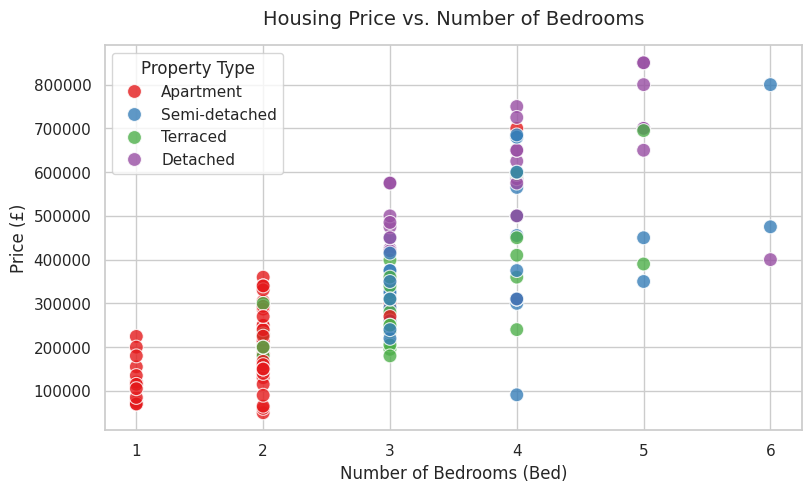

In [ ]:
# Create a scatterplot to explore how the number of bedrooms is associated with house prices
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_clean, x='Bed', y='Price (£)', hue='Property type', palette='Set1', s=100, alpha=0.8)
plt.title('Housing Price vs. Number of Bedrooms', fontsize=14, pad=15)
plt.xlabel('Number of Bedrooms (Bed)', fontsize=12)
plt.ylabel('Price (£)', fontsize=12)
plt.legend(title='Property Type')
plt.show()

<Axes: xlabel='Property type', ylabel='Price (£)'>

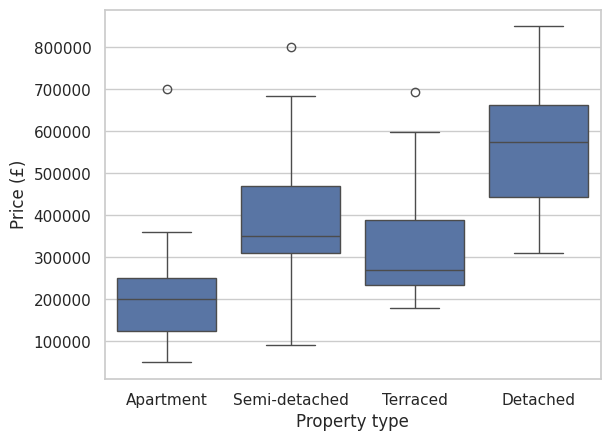

In [ ]:
# Generate a boxplot to compare house price distributions across different property types
sns.boxplot(
    data=df_clean,
    x='Property type',
    y='Price (£)'
)

#3. Model Development

We use Multiple Linear Regression mode because House price is a continuous variable, so it allows us to investigate the simultaneous effects of several predictors, including bedrooms, bathrooms, property type, and distances to amenities. The model also provides interpretable coefficients that can be used to explain housing price drivers.







> First Model



In [ ]:

X = df_model.drop(columns=['Price (£)'])
y = df_model['Price (£)']

X = sm.add_constant(X)

full_model = sm.OLS(y, X.astype(float)).fit()
print(full_model.summary())



                            OLS Regression Results                            
Dep. Variable:              Price (£)   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     52.20
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           9.59e-36
Time:                        14:15:35   Log-Likelihood:                -1886.1
No. Observations:                 146   AIC:                             3788.
Df Residuals:                     138   BIC:                             3812.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             



> Second Model





In [ ]:
significant_features_reduced_1 = ['const', 'Bed', 'Bath', 'Nearest station (miles)', 'Nearest school', 'Property type_Detached', 'Property type_Semi-detached']
X_reduced = X[significant_features_reduced_1]

model_reduced1 = sm.OLS(y, X_reduced.astype(float)).fit()
print(model_reduced1.summary())

                            OLS Regression Results                            
Dep. Variable:              Price (£)   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     61.25
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.25e-36
Time:                        14:15:35   Log-Likelihood:                -1886.1
No. Observations:                 146   AIC:                             3786.
Df Residuals:                     139   BIC:                             3807.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             



> Third Model



In [ ]:
significant_features_reduced_2 = ['const', 'Bed', 'Bath', 'Nearest station (miles)', 'Property type_Detached', 'Property type_Semi-detached']
X_reduced_2 = X[significant_features_reduced_2]

model_reduced2 = sm.OLS(y, X_reduced_2.astype(float)).fit()
print(model_reduced2 .summary())

                            OLS Regression Results                            
Dep. Variable:              Price (£)   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     73.21
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           2.42e-37
Time:                        14:15:35   Log-Likelihood:                -1886.7
No. Observations:                 146   AIC:                             3785.
Df Residuals:                     140   BIC:                             3803.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             



> Final Model






In [ ]:
significant_features_reduced_3 = ['const', 'Bed', 'Bath', 'Nearest station (miles)', 'Property type_Detached']
X_reduced_3 = X[significant_features_reduced_3]

model_reduced3 = sm.OLS(y, X_reduced_3.astype(float)).fit()
print(model_reduced3 .summary())


                            OLS Regression Results                            
Dep. Variable:              Price (£)   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     90.23
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           6.89e-38
Time:                        14:15:35   Log-Likelihood:                -1887.8
No. Observations:                 146   AIC:                             3786.
Df Residuals:                     141   BIC:                             3801.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   -1

In [ ]:
 #Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                      Variable        VIF
0                        const  23.558276
1                          Bed   3.138955
2                         Bath   1.259935
3      Nearest station (miles)   1.133025
4               Nearest school   1.058389
5       Property type_Detached   2.678169
6  Property type_Semi-detached   2.920590
7       Property type_Terraced   2.098922


All VIF values are below 5, indicating no serious multicollinearity among predictors.

In [ ]:
final_model = sm.OLS(y, X_reduced_3).fit()


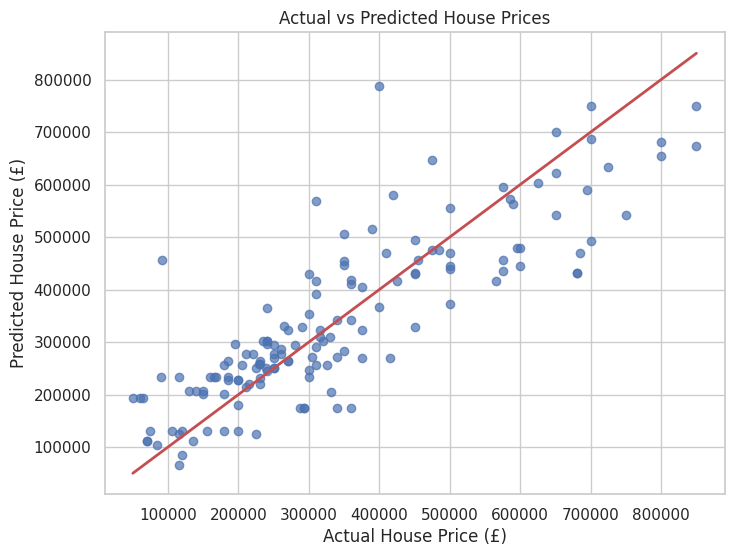

In [ ]:
# Generate predictions from the final model
y_pred = final_model.predict(X_reduced_3)

# Actual vs Predicted Plot
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(y, y_pred, alpha=0.7)

# Perfect prediction line
ax.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r',
    lw=2
)

ax.set_xlabel('Actual House Price (£)')
ax.set_ylabel('Predicted House Price (£)')
ax.set_title('Actual vs Predicted House Prices')

plt.show()

#Assumptions



> 1. Zero mean of residuals





In [ ]:

# Step 1: Extract residuals
residuals = model_reduced3.resid

# Step 2: Compute mean of residuals
mean_residual = residuals.mean()

# Step 3: Print result
print(f"Mean of residuals: {mean_residual:.6f}")


Mean of residuals: -0.000000




> 2. Normality of Residuals



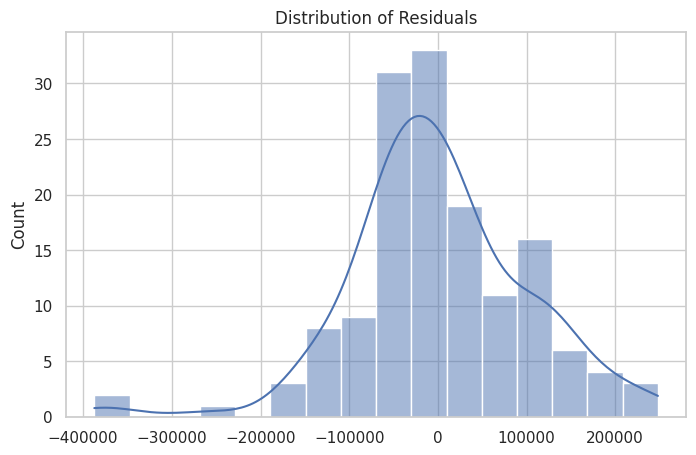

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals") # Update title
plt.show()

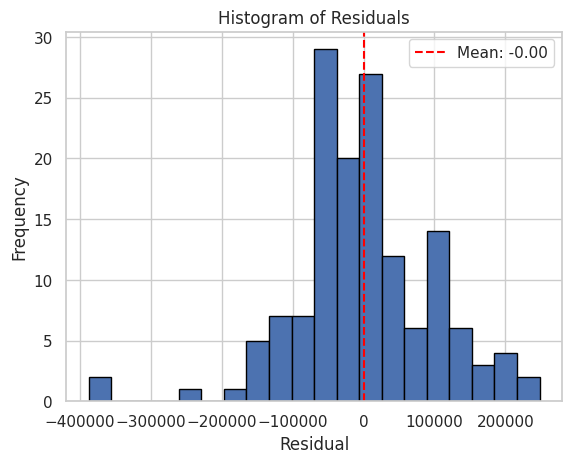

In [ ]:

residuals = model_reduced3.resid

plt.hist(residuals, bins=20, edgecolor='black')
plt.axvline(residuals.mean(), color='red', linestyle='--', label=f"Mean: {residuals.mean():.2f}")
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.2980392156862745, 0.4470588235294118, 0.6901960784313725, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


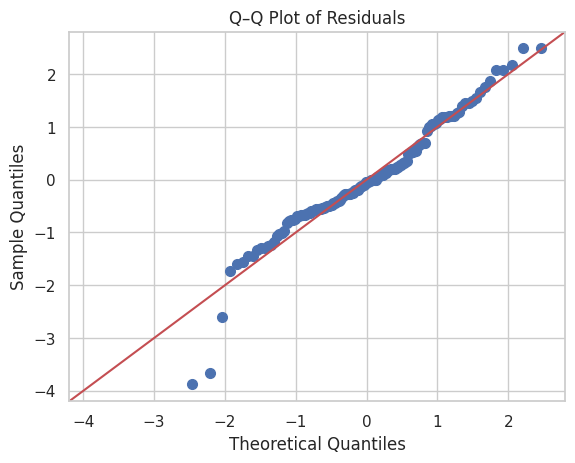

In [ ]:
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca(),
          markersize=7, color='dodgerblue', alpha=1.0)
plt.title("Q–Q Plot of Residuals")
plt.show()



>
3. Constant Error Variance



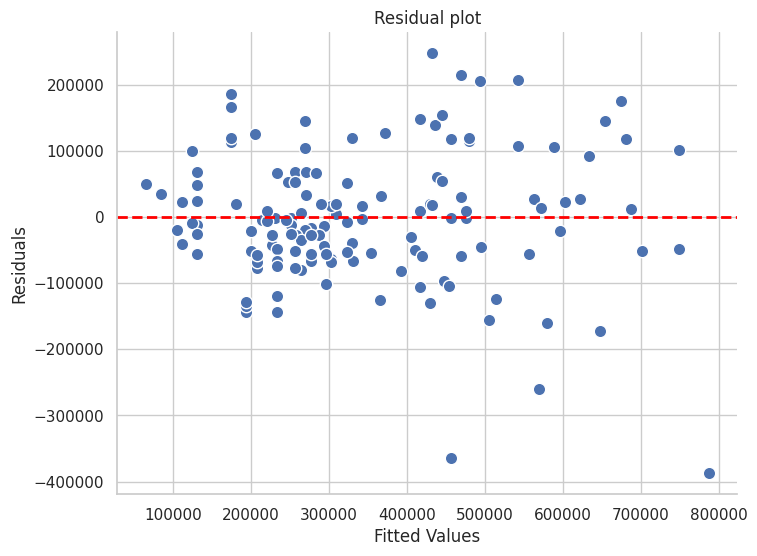

In [ ]:
#Homoscedasticity
plt.figure(figsize=(8, 6))
sns.scatterplot(x=model_reduced3.predict(), y=model_reduced3.resid, alpha=1.0, s=80,linewidth=1)
sns.despine()
plt.axhline(0, color='red', linestyle='--',linewidth=2)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual plot")
plt.show()



> 4. Independence of the errors



In [ ]:

from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(model_reduced3.resid)
print(f"Durbin–Watson statistic: {dw_stat:.4f}")

Durbin–Watson statistic: 2.1132



This value is very close to 2.0, and well within the safe range (1.5–2.5). The residuals in the regression model appear to be independent — there is no evidence of autocorrelation.